[*********************100%***********************]  1 of 1 completed

Using device: cpu

PART 2: Fetching Google Stock Data
Price           Close       High        Low       Open     Volume
Ticker          GOOGL      GOOGL      GOOGL      GOOGL      GOOGL
Date                                                             
2010-01-04  15.555865  15.624369  15.493568  15.560829   78169752
2010-01-05  15.487362  15.582919  15.426554  15.566538  120067812
2010-01-06  15.096946  15.533776  15.049788  15.533776  158988852
2010-01-07  14.745495  15.140132  14.709507  15.125239  256315428
2010-01-08  14.942070  14.972598  14.621644  14.693374  188783028

Total data points: 3753

PART 3: Preprocessing Data
X_train: (2942, 60, 1)  |  y_train: (2942, 1)
X_test : (691, 60, 1)   |  y_test : (691, 1)

PART 4 & 5: Building & Training LSTM Model
LSTMModel(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc1): Linear(in_features=50, out_features=25, bias=True)
  (fc2): Linear(in_features=25, out_features=1, bias=True)
  (relu): ReLU()
)


[LSTM] Epoch 01/10  Train Loss: 0.035167  Val Loss: 0.019110
[LSTM] Epoch 02/10  Train Loss: 0.000926  Val Loss: 0.006221
[LSTM] Epoch 03/10  Train Loss: 0.000284  Val Loss: 0.003583
[LSTM] Epoch 04/10  Train Loss: 0.000157  Val Loss: 0.002274
[LSTM] Epoch 05/10  Train Loss: 0.000128  Val Loss: 0.001869
[LSTM] Epoch 06/10  Train Loss: 0.000117  Val Loss: 0.001626
[LSTM] Epoch 07/10  Train Loss: 0.000128  Val Loss: 0.001690
[LSTM] Epoch 08/10  Train Loss: 0.000129  Val Loss: 0.001475
[LSTM] Epoch 09/10  Train Loss: 0.000125  Val Loss: 0.001369
[LSTM] Epoch 10/10  Train Loss: 0.000104  Val Loss: 0.001244

PART 6: Evaluating & Visualizing LSTM
LSTM  →  RMSE: 6.3133  |  MAE: 5.0005


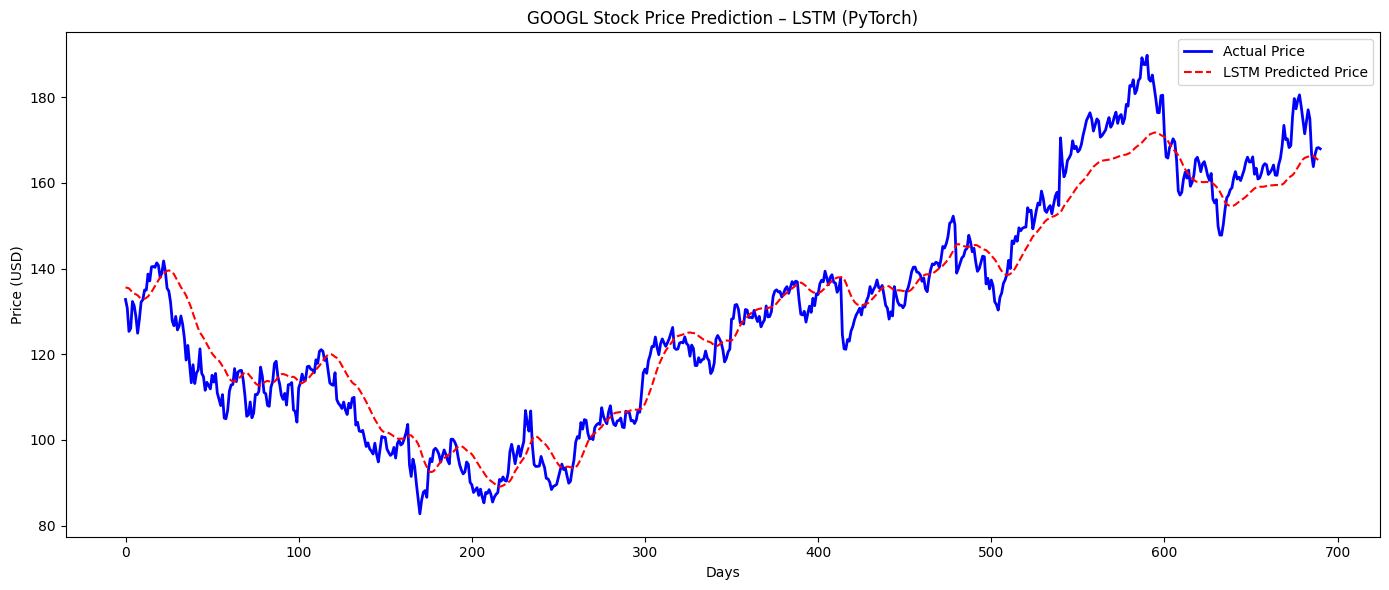

Saved: lstm_prediction_pytorch.png

PART 7: Next Day Price Prediction
Predicted next day's GOOGL price: $164.81

TASK 1: LSTM vs Simple RNN Comparison
SimpleRNNModel(
  (rnn): RNN(1, 50, num_layers=2, batch_first=True)
  (fc1): Linear(in_features=50, out_features=25, bias=True)
  (fc2): Linear(in_features=25, out_features=1, bias=True)
  (relu): ReLU()
)
[SimpleRNN] Epoch 01/10  Train Loss: 0.032192  Val Loss: 0.038066
[SimpleRNN] Epoch 02/10  Train Loss: 0.000488  Val Loss: 0.002501
[SimpleRNN] Epoch 03/10  Train Loss: 0.000092  Val Loss: 0.001979
[SimpleRNN] Epoch 04/10  Train Loss: 0.000078  Val Loss: 0.002095
[SimpleRNN] Epoch 05/10  Train Loss: 0.000080  Val Loss: 0.001734
[SimpleRNN] Epoch 06/10  Train Loss: 0.000117  Val Loss: 0.001705
[SimpleRNN] Epoch 07/10  Train Loss: 0.000096  Val Loss: 0.002333
[SimpleRNN] Epoch 08/10  Train Loss: 0.000097  Val Loss: 0.001503
[SimpleRNN] Epoch 09/10  Train Loss: 0.000078  Val Loss: 0.001436
[SimpleRNN] Epoch 10/10  Train Loss: 0.000088  Va

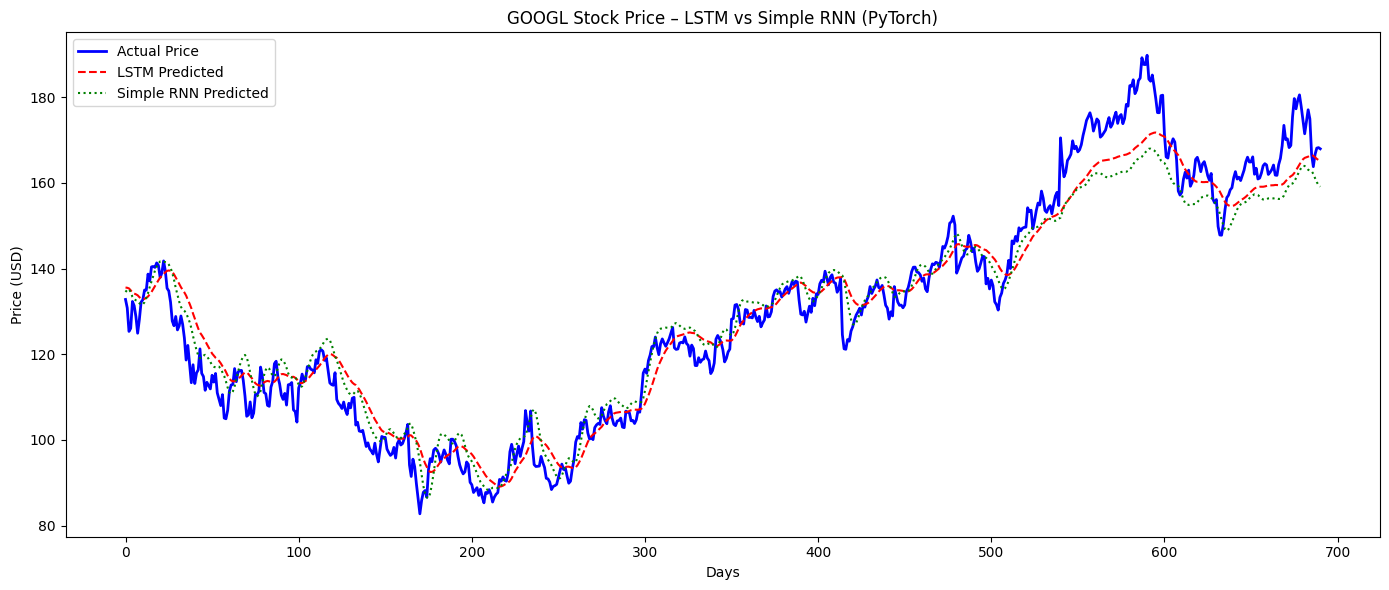

Saved: lstm_vs_rnn_pytorch.png


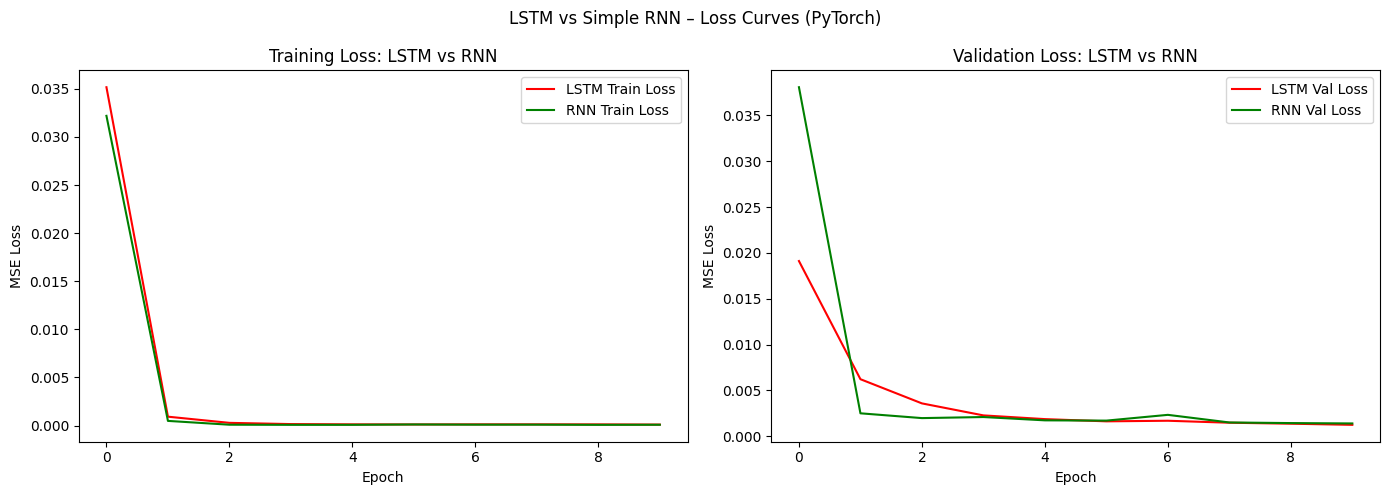

Saved: loss_curves_pytorch.png

----------------------------------------
Model                 RMSE        MAE
----------------------------------------
LSTM                6.3133     5.0005
Simple RNN          6.6883     5.1774
----------------------------------------
Better model (lower RMSE): LSTM

TASK 2: LSTM for Sentiment Analysis (IMDB)
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
LSTMSentiment(
  (embedding): Embedding(10000, 64, padding_idx=0)
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=64, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)
[Sentiment] Epoch 01/5  Train Loss: 0.6926  Acc: 0.5118  |  Val Loss: 0.6919  Acc: 0.5220
[Sentiment] Epoch 02/5  Train Loss: 0.6925  Acc: 0.5107  |  Val Loss: 0.6919  Acc: 0.4999
[Sentiment] Epoch 03/5  Train Loss: 0.6923  Acc: 0.5050  |  Val Loss: 0.6928  Acc: 0.5

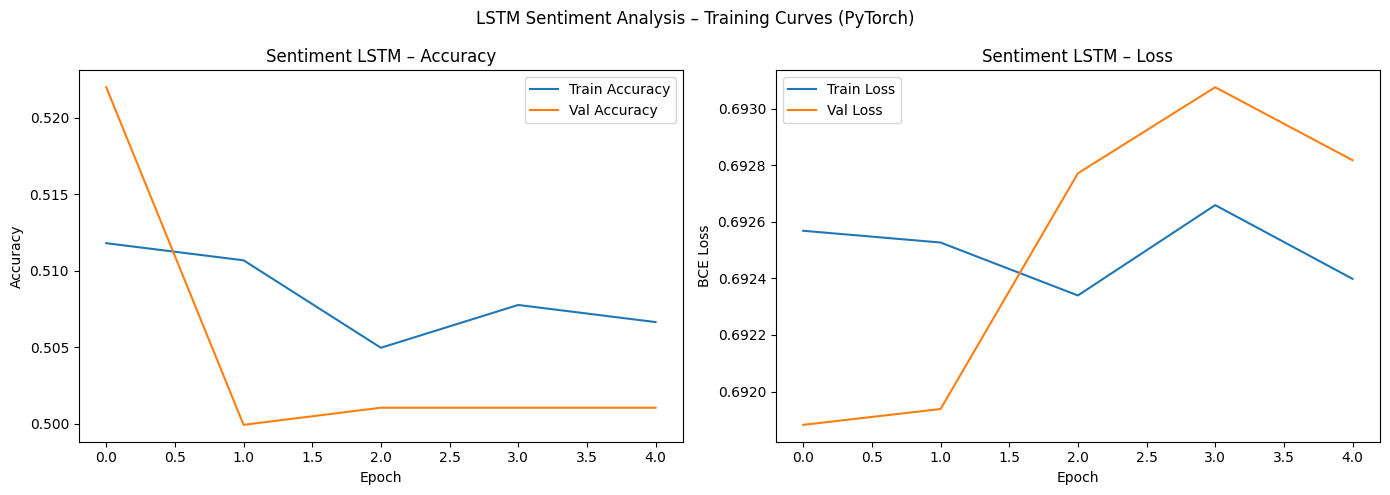

Saved: sentiment_lstm_pytorch.png
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

── Custom Review Predictions ──
  Review : This movie was absolutely fantastic and I loved every moment
  Result : POSITIVE  (confidence: 50.50%)

  Review : Terrible film complete waste of time very boring and disappo
  Result : POSITIVE  (confidence: 50.50%)

All done! Output files saved to /mnt/user-data/outputs/


In [ ]:

# PART 1: IMPORT LIBRARIES
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Create output directory if it doesn't exist
output_dir = '/mnt/user-data/outputs/'
os.makedirs(output_dir, exist_ok=True)

# ─────────────────────────────────────────────
# PART 2: FETCH GOOGLE STOCK DATA
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("PART 2: Fetching Google Stock Data")
print("=" * 60)

df = yf.download('GOOGL', start='2010-01-01', end='2024-12-01')
print(df.head())

data = df['Close'].values.reshape(-1, 1)
print(f"\nTotal data points: {len(data)}")

# ─────────────────────────────────────────────
# PART 3: PREPROCESS DATA
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("PART 3: Preprocessing Data")
print("=" * 60)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data  = scaled_data[train_size:]

SEQUENCE_LENGTH = 60

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_data, SEQUENCE_LENGTH)
X_test,  y_test  = create_sequences(test_data,  SEQUENCE_LENGTH)

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   |  y_test : {y_test.shape}")

# ── PyTorch Dataset & DataLoader ──
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)          # (N, seq_len, 1)
        self.y = torch.tensor(y)          # (N, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(StockDataset(X_test,  y_test),  batch_size=32, shuffle=False)

# ─────────────────────────────────────────────
# PART 4 & 5: LSTM MODEL — BUILD & TRAIN
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("PART 4 & 5: Building & Training LSTM Model")
print("=" * 60)

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=0.0)
        self.fc1  = nn.Linear(hidden_size, 25)
        self.fc2  = nn.Linear(25, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))   # out: (batch, seq_len, hidden)
        out = out[:, -1, :]               # last time step
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out


def train_model(model, train_loader, test_loader, epochs=10, lr=1e-3, model_name="Model"):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ── Training ──
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * X_batch.size(0)
        train_loss = epoch_loss / len(train_loader.dataset)

        # ── Validation ──
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                preds    = model(X_batch)
                val_loss += criterion(preds, y_batch).item() * X_batch.size(0)
        val_loss /= len(test_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"[{model_name}] Epoch {epoch+1:02d}/{epochs}  "
              f"Train Loss: {train_loss:.6f}  Val Loss: {val_loss:.6f}")

    return train_losses, val_losses


def get_predictions(model, loader):
    model.eval()
    preds_list, true_list = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            out = model(X_batch).cpu().numpy()
            preds_list.append(out)
            true_list.append(y_batch.numpy())
    preds = np.vstack(preds_list)
    trues = np.vstack(true_list)
    preds = scaler.inverse_transform(preds)
    trues = scaler.inverse_transform(trues)
    return preds, trues


lstm_model = LSTMModel()
print(lstm_model)

lstm_train_loss, lstm_val_loss = train_model(
    lstm_model, train_loader, test_loader, epochs=10, model_name="LSTM"
)

# ─────────────────────────────────────────────
# PART 6: EVALUATE AND VISUALIZE
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("PART 6: Evaluating & Visualizing LSTM")
print("=" * 60)

lstm_preds, y_actual = get_predictions(lstm_model, test_loader)

lstm_rmse = np.sqrt(mean_squared_error(y_actual, lstm_preds))
lstm_mae  = mean_absolute_error(y_actual, lstm_preds)
print(f"LSTM  →  RMSE: {lstm_rmse:.4f}  |  MAE: {lstm_mae:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(y_actual,    label='Actual Price',          color='blue', linewidth=2)
plt.plot(lstm_preds,  label='LSTM Predicted Price',  color='red',  linestyle='--')
plt.title('GOOGL Stock Price Prediction – LSTM (PyTorch)')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/lstm_prediction_pytorch.png', dpi=150)
plt.show()
print("Saved: lstm_prediction_pytorch.png")

# ─────────────────────────────────────────────
# PART 7: PREDICT FUTURE (NEXT DAY)
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("PART 7: Next Day Price Prediction")
print("=" * 60)

last_seq = torch.tensor(
    scaled_data[-SEQUENCE_LENGTH:].reshape(1, SEQUENCE_LENGTH, 1),
    dtype=torch.float32
).to(DEVICE)

lstm_model.eval()
with torch.no_grad():
    next_scaled = lstm_model(last_seq).cpu().numpy()

next_price = scaler.inverse_transform(next_scaled)
print(f"Predicted next day's GOOGL price: ${next_price[0][0]:.2f}")

# ══════════════════════════════════════════════════════════════
# ████████  TASK 1: COMPARE LSTM vs Simple RNN  ████████████
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("TASK 1: LSTM vs Simple RNN Comparison")
print("=" * 60)

class SimpleRNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super(SimpleRNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                          batch_first=True, nonlinearity='tanh')
        self.fc1 = nn.Linear(hidden_size, 25)
        self.fc2 = nn.Linear(25, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        h0  = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out = out[:, -1, :]
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out


rnn_model = SimpleRNNModel()
print(rnn_model)

rnn_train_loss, rnn_val_loss = train_model(
    rnn_model, train_loader, test_loader, epochs=10, model_name="SimpleRNN"
)

rnn_preds, _ = get_predictions(rnn_model, test_loader)

rnn_rmse = np.sqrt(mean_squared_error(y_actual, rnn_preds))
rnn_mae  = mean_absolute_error(y_actual, rnn_preds)
print(f"Simple RNN  →  RMSE: {rnn_rmse:.4f}  |  MAE: {rnn_mae:.4f}")

# ── Prediction Comparison Plot ──
plt.figure(figsize=(14, 6))
plt.plot(y_actual,   label='Actual Price',          color='blue',  linewidth=2)
plt.plot(lstm_preds, label='LSTM Predicted',         color='red',   linestyle='--')
plt.plot(rnn_preds,  label='Simple RNN Predicted',  color='green', linestyle=':')
plt.title('GOOGL Stock Price – LSTM vs Simple RNN (PyTorch)')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/lstm_vs_rnn_pytorch.png', dpi=150)
plt.show()
print("Saved: lstm_vs_rnn_pytorch.png")

# ── Loss Curve Comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lstm_train_loss, label='LSTM Train Loss',    color='red')
axes[0].plot(rnn_train_loss,  label='RNN Train Loss',     color='green')
axes[0].set_title('Training Loss: LSTM vs RNN')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(lstm_val_loss, label='LSTM Val Loss',   color='red')
axes[1].plot(rnn_val_loss,  label='RNN Val Loss',    color='green')
axes[1].set_title('Validation Loss: LSTM vs RNN')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()

plt.suptitle('LSTM vs Simple RNN – Loss Curves (PyTorch)')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/loss_curves_pytorch.png', dpi=150)
plt.show()
print("Saved: loss_curves_pytorch.png")

# ── Metrics Table ──
print("\n" + "-" * 40)
print(f"{'Model':<15} {'RMSE':>10} {'MAE':>10}")
print("-" * 40)
print(f"{'LSTM':<15} {lstm_rmse:>10.4f} {lstm_mae:>10.4f}")
print(f"{'Simple RNN':<15} {rnn_rmse:>10.4f} {rnn_mae:>10.4f}")
print("-" * 40)
winner = "LSTM" if lstm_rmse < rnn_rmse else "Simple RNN"
print(f"Better model (lower RMSE): {winner}")

# ══════════════════════════════════════════════════════════════
# ████████  TASK 2: LSTM SENTIMENT ANALYSIS  ██████████████████
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("TASK 2: LSTM for Sentiment Analysis (IMDB)")
print("=" * 60)

# ── Load IMDB via Keras (for convenience) ──
from tensorflow.keras.datasets import imdb as keras_imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_FEATURES = 10000
MAX_LEN      = 200

(X_tr, y_tr), (X_te, y_te) = keras_imdb.load_data(num_words=MAX_FEATURES)

X_tr = pad_sequences(X_tr, maxlen=MAX_LEN, padding='post', truncating='post')
X_te = pad_sequences(X_te, maxlen=MAX_LEN, padding='post', truncating='post')

X_tr = torch.tensor(X_tr, dtype=torch.long)
y_tr = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
X_te = torch.tensor(X_te, dtype=torch.long)
y_te = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)

class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

sa_train_loader = DataLoader(SentimentDataset(X_tr, y_tr), batch_size=64, shuffle=True)
sa_test_loader  = DataLoader(SentimentDataset(X_te, y_te), batch_size=64, shuffle=False)

# ── LSTM Sentiment Model ──
class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size=MAX_FEATURES, embed_dim=64,
                 hidden_size=64, num_layers=2, output_size=1):
        super(LSTMSentiment, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_size, num_layers,
                                 batch_first=True, dropout=0.3)
        self.dropout   = nn.Dropout(0.3)
        self.fc1       = nn.Linear(hidden_size, 16)
        self.fc2       = nn.Linear(16, output_size)
        self.relu      = nn.ReLU()
        self.sigmoid   = nn.Sigmoid()

    def forward(self, x):
        emb = self.embedding(x)                           # (B, seq, embed_dim)
        out, (h_n, _) = self.lstm(emb)                   # h_n: (num_layers, B, hidden)
        out = self.dropout(h_n[-1])                       # last layer hidden state
        out = self.relu(self.fc1(out))
        out = self.sigmoid(self.fc2(out))
        return out


sa_model   = LSTMSentiment().to(DEVICE)
sa_criterion = nn.BCELoss()
sa_optimizer = torch.optim.Adam(sa_model.parameters(), lr=1e-3)

print(sa_model)

sa_train_losses, sa_val_losses   = [], []
sa_train_accs,   sa_val_accs     = [], []

EPOCHS_SA = 5
for epoch in range(EPOCHS_SA):
    # ── Train ──
    sa_model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for X_b, y_b in sa_train_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        sa_optimizer.zero_grad()
        out  = sa_model(X_b)
        loss = sa_criterion(out, y_b)
        loss.backward()
        sa_optimizer.step()
        t_loss    += loss.item() * X_b.size(0)
        preds      = (out >= 0.5).float()
        t_correct += (preds == y_b).sum().item()
        t_total   += X_b.size(0)

    # ── Validate ──
    sa_model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for X_b, y_b in sa_test_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            out  = sa_model(X_b)
            loss = sa_criterion(out, y_b)
            v_loss    += loss.item() * X_b.size(0)
            preds      = (out >= 0.5).float()
            v_correct += (preds == y_b).sum().item()
            v_total   += X_b.size(0)

    tl = t_loss / t_total;  ta = t_correct / t_total
    vl = v_loss / v_total;  va = v_correct / v_total
    sa_train_losses.append(tl);  sa_val_losses.append(vl)
    sa_train_accs.append(ta);    sa_val_accs.append(va)

    print(f"[Sentiment] Epoch {epoch+1:02d}/{EPOCHS_SA}  "
          f"Train Loss: {tl:.4f}  Acc: {ta:.4f}  |  "
          f"Val Loss: {vl:.4f}  Acc: {va:.4f}")

print(f"\nFinal Test Accuracy: {sa_val_accs[-1]:.4f}")

# ── Plot Training Curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sa_train_accs, label='Train Accuracy')
axes[0].plot(sa_val_accs,   label='Val Accuracy')
axes[0].set_title('Sentiment LSTM – Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(sa_train_losses, label='Train Loss')
axes[1].plot(sa_val_losses,   label='Val Loss')
axes[1].set_title('Sentiment LSTM – Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('BCE Loss')
axes[1].legend()

plt.suptitle('LSTM Sentiment Analysis – Training Curves (PyTorch)')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/sentiment_lstm_pytorch.png', dpi=150)
plt.show()
print("Saved: sentiment_lstm_pytorch.png")

# ── Demo Inference ──
word_index = keras_imdb.get_word_index()

def encode_review(text, word_index, max_len=MAX_LEN, max_features=MAX_FEATURES):
    tokens = text.lower().split()
    ids = []
    for w in tokens:
        idx = word_index.get(w, 2)
        if idx < max_features:
            ids.append(idx + 3)
    ids = ids[:max_len]
    padded = np.zeros((1, max_len), dtype=np.int64)
    padded[0, :len(ids)] = ids
    return torch.tensor(padded, dtype=torch.long)

reviews = [
    "This movie was absolutely fantastic and I loved every moment of it",
    "Terrible film complete waste of time very boring and disappointing"
]

print("\n── Custom Review Predictions ──")
sa_model.eval()
for review in reviews:
    enc  = encode_review(review, word_index).to(DEVICE)
    with torch.no_grad():
        prob = sa_model(enc).item()
    label = "POSITIVE" if prob >= 0.5 else "NEGATIVE"
    print(f"  Review : {review[:60]}")
    print(f"  Result : {label}  (confidence: {prob:.2%})\n")

print("=" * 60)
print("All done! Output files saved to /mnt/user-data/outputs/")
print("=" * 60)